In [95]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

In [96]:
def getCSV(csv):
    raw_df = pd.read_csv(csv)
    return raw_df
csv = r'C:\Users\Tom\OneDrive\Documents\APROJECTS\GrasslandCover.csv'
df = getCSV(csv)
print(df)

                                       STATISTIC Label  Year County and State  \
0    Percentage of area of each county covered by e...  2018       Co. Carlow   
1    Percentage of area of each county covered by e...  2018       Co. Carlow   
2    Percentage of area of each county covered by e...  2018       Co. Carlow   
3    Percentage of area of each county covered by e...  2018       Co. Carlow   
4    Percentage of area of each county covered by e...  2018       Co. Carlow   
..                                                 ...   ...              ...   
211  Percentage of area of each county covered by e...  2018          Ireland   
212  Percentage of area of each county covered by e...  2018          Ireland   
213  Percentage of area of each county covered by e...  2018          Ireland   
214  Percentage of area of each county covered by e...  2018          Ireland   
215  Percentage of area of each county covered by e...  2018          Ireland   

                        Typ

In [97]:
COUNTIES_COLUMN = 'County and State'

In [98]:
def editCounties(df_edit):
    df_edit[COUNTIES_COLUMN] = df_edit[COUNTIES_COLUMN].apply(lambda x:x[4:])
    print(df_edit)
    return df_edit
df = editCounties(df)

                                       STATISTIC Label  Year County and State  \
0    Percentage of area of each county covered by e...  2018           Carlow   
1    Percentage of area of each county covered by e...  2018           Carlow   
2    Percentage of area of each county covered by e...  2018           Carlow   
3    Percentage of area of each county covered by e...  2018           Carlow   
4    Percentage of area of each county covered by e...  2018           Carlow   
..                                                 ...   ...              ...   
211  Percentage of area of each county covered by e...  2018              and   
212  Percentage of area of each county covered by e...  2018              and   
213  Percentage of area of each county covered by e...  2018              and   
214  Percentage of area of each county covered by e...  2018              and   
215  Percentage of area of each county covered by e...  2018              and   

                        Typ

In [99]:
counties_shapefile = gpd.read_file(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\Ireland_Counties\Counties___Ungen_2019.shp')

In [100]:
df[COUNTIES_COLUMN] = df[COUNTIES_COLUMN].str.upper()
print(df)

                                       STATISTIC Label  Year County and State  \
0    Percentage of area of each county covered by e...  2018           CARLOW   
1    Percentage of area of each county covered by e...  2018           CARLOW   
2    Percentage of area of each county covered by e...  2018           CARLOW   
3    Percentage of area of each county covered by e...  2018           CARLOW   
4    Percentage of area of each county covered by e...  2018           CARLOW   
..                                                 ...   ...              ...   
211  Percentage of area of each county covered by e...  2018              AND   
212  Percentage of area of each county covered by e...  2018              AND   
213  Percentage of area of each county covered by e...  2018              AND   
214  Percentage of area of each county covered by e...  2018              AND   
215  Percentage of area of each county covered by e...  2018              AND   

                        Typ

In [101]:
filtered_df = df[df['Type of grassland and cropland'] == 'Grassland - All grasslands (CLC)']
print(filtered_df)

                                       STATISTIC Label  Year County and State  \
5    Percentage of area of each county covered by e...  2018           CARLOW   
13   Percentage of area of each county covered by e...  2018            CAVAN   
21   Percentage of area of each county covered by e...  2018            CLARE   
29   Percentage of area of each county covered by e...  2018             CORK   
37   Percentage of area of each county covered by e...  2018          DONEGAL   
45   Percentage of area of each county covered by e...  2018           DUBLIN   
53   Percentage of area of each county covered by e...  2018           GALWAY   
61   Percentage of area of each county covered by e...  2018            KERRY   
69   Percentage of area of each county covered by e...  2018          KILDARE   
77   Percentage of area of each county covered by e...  2018         KILKENNY   
85   Percentage of area of each county covered by e...  2018            LAOIS   
93   Percentage of area of e

In [102]:
def mergeData(df):
    merged_data = counties_shapefile.merge(df, how='left', left_on='ENGLISH', right_on=COUNTIES_COLUMN)
    return merged_data
merged_data = mergeData(filtered_df)

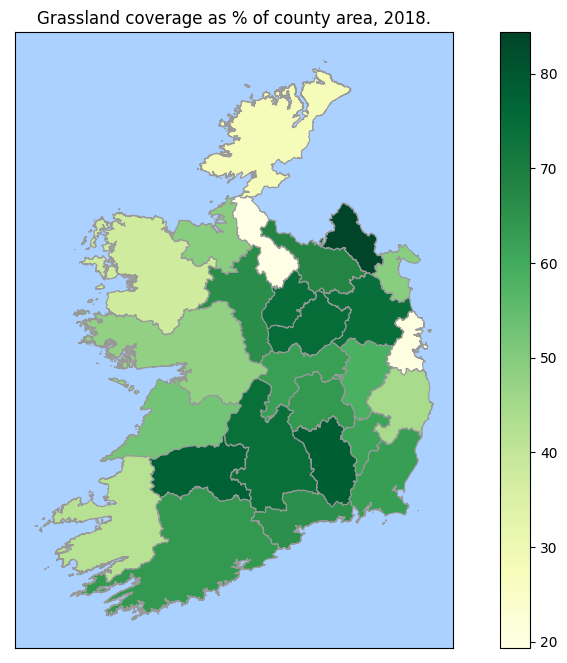

In [121]:
import numpy as np

#column containing the population values
column_to_plot = 'VALUE'

# merged_data['scaled_value'] = np.log1p(merged_data['VALUE'])

#plot the populastion data for the selcted year on the map generated by the shapefile
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged_data.plot(column=column_to_plot, cmap='YlGn', linewidth=0.8, ax=ax, edgecolor='0.60', legend=True)
title_string = "Grassland coverage as % of county area, 2018."
ax.set_title(title_string)

ax.set_facecolor('#AAD1FF') 

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

#plt.savefig('Grassland-Coverage-2018.png')
plt.show()

In [104]:
#do it for croplands in same csv
filtered_df = df[df['Type of grassland and cropland'] == 'Croplands - All croplands (CLC)']

In [105]:
merged_data_crop = mergeData(filtered_df)

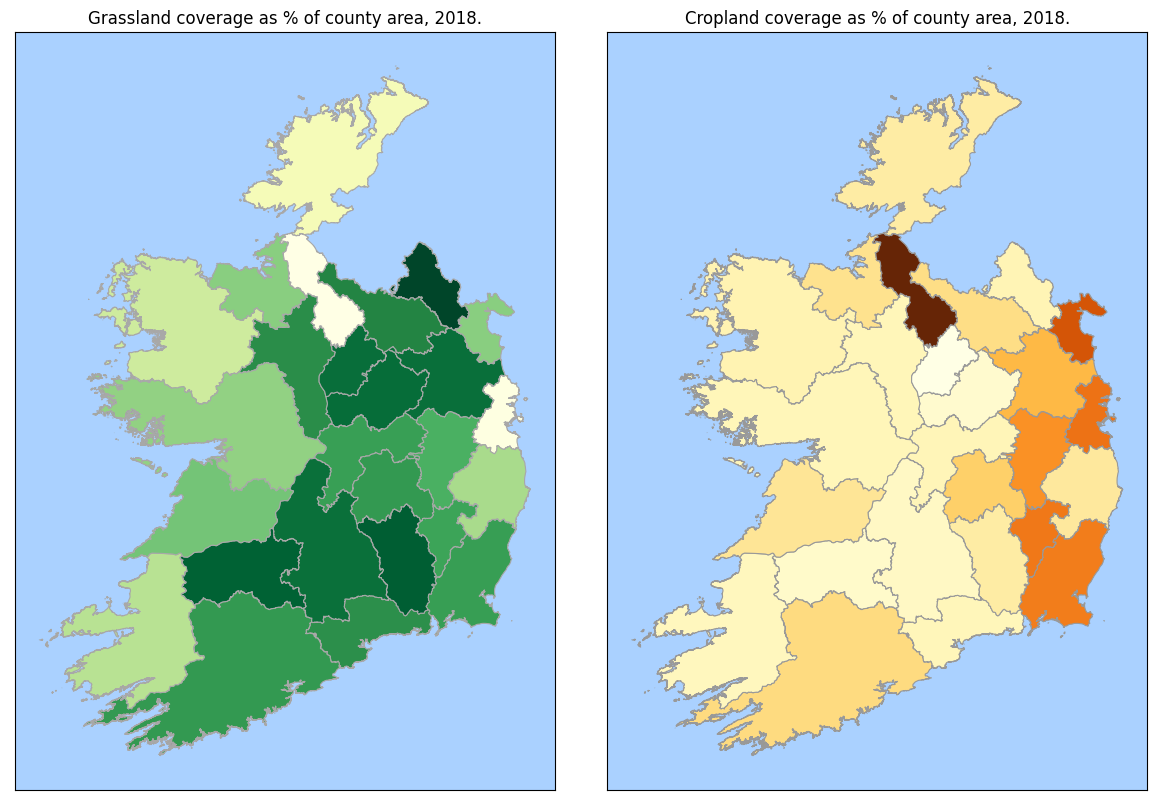

In [124]:
import numpy as np

#column containing the population values
column_to_plot = 'VALUE'

# merged_data['scaled_value'] = np.log1p(merged_data['VALUE'])

#plot the populastion data for the selcted year on the map generated by the shapefile
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

#GRASSLAND
merged_data.plot(column=column_to_plot, cmap='YlGn', linewidth=0.8, ax=ax[0], edgecolor='0.66', legend=False)
title_string = "Grassland coverage as % of county area, 2018."
ax[0].set_title(title_string)
ax[0].set_facecolor('#FFFFFF') 
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_facecolor('#AAD1FF') 

#CROPLAND
merged_data_crop.plot(column=column_to_plot, cmap='YlOrBr', linewidth=0.8, ax=ax[1], edgecolor='0.60', legend=False)
title_string = "Cropland coverage as % of county area, 2018."
ax[1].set_title(title_string)
ax[1].set_facecolor('#FFFFFF') 
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_facecolor('#AAD1FF') 

plt.tight_layout()

plt.savefig('Cropland-Coverage-2018.png')
plt.show()